In [1]:
%pip install transformers torch datasets pandas scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import numpy as np
import pandas as pd
import torch
from datasets import Dataset
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from sklearn.model_selection import train_test_split
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
)

SEED = 42
MODEL_NAME = "ProsusAI/finbert"
LABEL2ID = {"negative": 0, "neutral": 1, "positive": 2}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}

np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

c:\Users\DAVID SM\miniconda3\envs\python-gpu\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
DATA_PATH = os.path.abspath(os.path.join(os.getcwd(), "..", "data", "sentiment_dataset.csv"))
df = pd.read_csv(DATA_PATH)
df.head()

,text,sentiment,source
0,"Would Xiamen International Port Co., Ltd (HKG:...",neutral,twitter
1,Goldman Sachs stock price target raised to $36...,positive,twitter
2,Nike to record $425 mln charge as it transitio...,negative,twitter
3,Ocean impact investment fund reaches $92m seco...,neutral,twitter
4,Last day to sign up for a discount to our comm...,neutral,twitter


In [4]:
df["source"].value_counts()

source
twitter    11931
news        4327
Name: count, dtype: int64

In [5]:
print(f"Tamaño del dataset: {len(df)}")

Tamaño del dataset: 16258


In [6]:
df = df[["text", "sentiment"]].copy()
df["text"] = df["text"].astype(str).str.strip()
df["sentiment"] = df["sentiment"].astype(str).str.strip().str.lower()

df = df.dropna(subset=["text", "sentiment"])
df = df[df["text"] != ""]
df = df[df["sentiment"].isin(LABEL2ID.keys())]
df = df.drop_duplicates(subset=["text", "sentiment"]).reset_index(drop=True)

# Mapeo de sentimientos a índices numéricos
df["label"] = df["sentiment"].map(LABEL2ID).astype(int)

print(f"Total de muestras limpias: {len(df):,}")
print(df["sentiment"].value_counts())
df.head()

Total de muestras limpias: 16,255
sentiment
neutral     10080
positive     3877
negative     2298
Name: count, dtype: int64


,text,sentiment,label
0,"Would Xiamen International Port Co., Ltd (HKG:...",neutral,1
1,Goldman Sachs stock price target raised to $36...,positive,2
2,Nike to record $425 mln charge as it transitio...,negative,0
3,Ocean impact investment fund reaches $92m seco...,neutral,1
4,Last day to sign up for a discount to our comm...,neutral,1


In [7]:
_, test_df = train_test_split(
    df,
    test_size=0.1,
    random_state=SEED,
    stratify=df["label"],
)

In [8]:
test_ds = Dataset.from_pandas(test_df[["text", "label"]].reset_index(drop=True))

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

In [9]:
def tokenize_batch(batch):
    return tokenizer(batch["text"], truncation=True, max_length=128)

test_tok = test_ds.map(tokenize_batch, batched=True)

cols = ["input_ids", "attention_mask", "label"]

test_tok.set_format(type="torch", columns=cols)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

Map: 100%|██████████| 1626/1626 [00:00<00:00, 18538.89 examples/s]


In [10]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label=ID2LABEL,
    label2id=LABEL2ID,
)

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 14170.90it/s]


In [11]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="weighted", zero_division=0
    )
    acc = accuracy_score(labels, preds)
    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }

In [12]:
from torch.utils.data import DataLoader

model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

all_logits, all_labels = [], []

loader = DataLoader(test_tok, batch_size=32, collate_fn=data_collator)

with torch.no_grad():
    for batch in loader:
        labels_batch = batch.pop("labels").to(device)
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**batch)
        all_logits.append(outputs.logits.cpu())
        all_labels.append(labels_batch.cpu())

all_logits = torch.cat(all_logits).numpy()
all_labels = torch.cat(all_labels).numpy()
probs = torch.softmax(torch.tensor(all_logits), dim=-1).numpy()
preds = probs.argmax(axis=-1)

CLASSIFICATION REPORT – Modelo Base
              precision    recall  f1-score   support

    negative     0.0384    0.0609    0.0471       230
     neutral     0.4251    0.1548    0.2269      1008
    positive     0.1152    0.2655    0.1607       388

    accuracy                         0.1679      1626
   macro avg     0.1929    0.1604    0.1449      1626
weighted avg     0.2964    0.1679    0.1857      1626



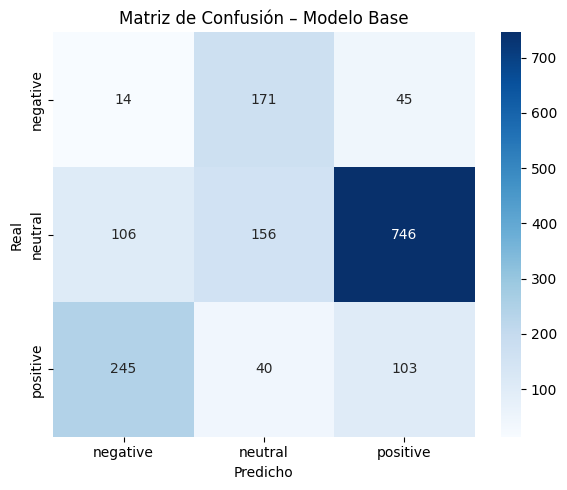

In [15]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt

print("=" * 60)
print("CLASSIFICATION REPORT – Modelo Base")
print("=" * 60)
print(classification_report(all_labels, preds,
      target_names=["negative", "neutral", "positive"], digits=4))

cm = confusion_matrix(all_labels, preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["negative", "neutral", "positive"],
            yticklabels=["negative", "neutral", "positive"])
plt.title("Matriz de Confusión – Modelo Base")
plt.ylabel("Real"); plt.xlabel("Predicho")
plt.tight_layout()
plt.savefig("confusion_matrix_base.png", dpi=150)
plt.show()

In [16]:
from sklearn.preprocessing import label_binarize

labels_bin = label_binarize(all_labels, classes=[0, 1, 2])
auc = roc_auc_score(labels_bin, probs, multi_class="ovr", average="weighted")
print(f"\nROC-AUC (weighted OvR): {auc:.4f}")


ROC-AUC (weighted OvR): 0.3351


In [17]:
example_texts = [
    "Goldman Sachs stock price target raised to $367 from $358 at Oppenheimer",
    "Baltic Dry Index sheds 5%",
    "Ocean impact investment fund reaches $92m second close",
]

def predict_texts(texts, model, tokenizer, max_length=128):
    if isinstance(texts, str):
        texts = [texts]
    device = model.device
    enc = tokenizer(texts, return_tensors="pt", truncation=True,
                    padding=True, max_length=max_length)
    enc = {k: v.to(device) for k, v in enc.items()}
    model.eval()
    with torch.no_grad():
        logits = model(**enc).logits
        probs  = torch.softmax(logits, dim=-1)
    logits_np = logits.cpu().numpy()
    probs_np  = probs.cpu().numpy()
    pred_ids  = probs_np.argmax(axis=-1)
    return [{
        "text": txt,
        "logits": logits_np[i].tolist(),
        "probabilities": probs_np[i].tolist(),
        "predicted_label": ID2LABEL[int(pred_ids[i])],
    } for i, txt in enumerate(texts)]

print("\n" + "=" * 60)
print("PREDICCIONES DE EJEMPLO – Modelo Base")
print("=" * 60)
for p in predict_texts(example_texts, model, tokenizer):
    print("-" * 100)
    print("Text:", p["text"])
    print("Logits [neg, neu, pos]:", np.round(p["logits"], 4))
    print("Probabilidades [neg, neu, pos]:", np.round(p["probabilities"], 4))
    print("Predicción:", p["predicted_label"])


PREDICCIONES DE EJEMPLO – Modelo Base
----------------------------------------------------------------------------------------------------
Text: Goldman Sachs stock price target raised to $367 from $358 at Oppenheimer
Logits [neg, neu, pos]: [ 1.9136 -1.7005 -1.4987]
Probabilidades [neg, neu, pos]: [0.9435 0.0254 0.0311]
Predicción: negative
----------------------------------------------------------------------------------------------------
Text: Baltic Dry Index sheds 5%
Logits [neg, neu, pos]: [-1.6329  2.8126 -0.866 ]
Probabilidades [neg, neu, pos]: [0.0113 0.9643 0.0244]
Predicción: neutral
----------------------------------------------------------------------------------------------------
Text: Ocean impact investment fund reaches $92m second close
Logits [neg, neu, pos]: [ 0.773  -2.2079  1.583 ]
Probabilidades [neg, neu, pos]: [0.3032 0.0154 0.6815]
Predicción: positive


In [18]:
def compute_ece(probs, labels, n_bins=10):
    confidences = probs.max(axis=-1)
    correct = (probs.argmax(axis=-1) == labels).astype(float)
    bins = np.linspace(0, 1, n_bins + 1)
    ece = 0
    for i in range(n_bins):
        mask = (confidences > bins[i]) & (confidences <= bins[i+1])
        if mask.sum() > 0:
            ece += abs(correct[mask].mean() - confidences[mask].mean()) * mask.sum()
    return ece / len(labels)

print(f"ECE (calibración):      {compute_ece(probs, all_labels):.4f}  (0 = perfecto)")

ECE (calibración):      0.6647  (0 = perfecto)


In [19]:
import math

loss_fn = torch.nn.CrossEntropyLoss()
ce_loss = loss_fn(torch.tensor(all_logits), torch.tensor(all_labels).long()).item()
ppl = math.exp(ce_loss)
print(f"Pseudo-Perplexity:      {ppl:.4f}")

Pseudo-Perplexity:      17.1734
